# CWRU Bearing Data Download & Exploration

Downloads the normal baseline and 48k-drive-end fault `.mat` files from CWRU's bearing data center into `data/` (skipping any already present), then explores the resulting dataset.

## 1. Download data

In [1]:
import os

import requests

DATA_DIR = "data"
NORMAL_DIR = os.path.join(DATA_DIR, "normal_baseline_data")
DRIVE_END_48K_DIR = os.path.join(DATA_DIR, "48k_drive_end_fault")
os.makedirs(NORMAL_DIR, exist_ok=True)
os.makedirs(DRIVE_END_48K_DIR, exist_ok=True)

# Normal baseline files: {load_hp: file_number}
normal_files = {0: 97, 1: 98, 2: 99, 3: 100}

# Approximate motor speed by load, per the CWRU bearing data center page.
LOAD_RPM = {0: 1797, 1: 1772, 2: 1750, 3: 1730}

In [2]:
def _entries(file_numbers, fault_location, fault_diameter_in, position=None):
    """Build {file_number: metadata} for one fault type/diameter across loads 0-3 hp."""
    entries = {}
    for file_number, load_hp in zip(file_numbers, sorted(LOAD_RPM)):
        meta = {
            "fault_location": fault_location,
            "fault_diameter_in": fault_diameter_in,
            "load_hp": load_hp,
            "rpm": LOAD_RPM[load_hp],
        }
        if position:
            meta["position"] = position
        entries[file_number] = meta
    return entries


# 48k drive-end bearing fault files: {file_number: metadata}.
# Source: https://engineering.case.edu/bearingdatacenter/48k-drive-end-bearing-fault-data
drive_end_48k_files = {
    **_entries([109, 110, 111, 112], "inner_race", 0.007),
    **_entries([122, 123, 124, 125], "ball", 0.007),
    **_entries([135, 136, 137, 138], "outer_race", 0.007, "6:00"),
    **_entries([148, 149, 150, 151], "outer_race", 0.007, "3:00"),
    **_entries([161, 162, 163, 164], "outer_race", 0.007, "12:00"),
    **_entries([174, 175, 176, 177], "inner_race", 0.014),
    **_entries([189, 190, 191, 192], "ball", 0.014),
    **_entries([201, 202, 203, 204], "outer_race", 0.014, "6:00"),
    **_entries([213, 214, 215, 217], "inner_race", 0.021),
    **_entries([226, 227, 228, 229], "ball", 0.021),
    **_entries([238, 239, 240, 241], "outer_race", 0.021, "6:00"),
    **_entries([250, 251, 252, 253], "outer_race", 0.021, "3:00"),
    **_entries([262, 263, 264, 265], "outer_race", 0.021, "12:00"),
}

In [3]:
base_url = "https://engineering.case.edu/sites/default/files/{}.mat"


def build_filename(file_number: int, meta: dict) -> str:
    """Turn a drive_end_48k_files entry into a descriptive filename."""
    parts = [
        "48k_drive_end_fault",
        meta["fault_location"],
        f"{meta['fault_diameter_in']:.3f}in",
        f"{meta['load_hp']}hp",
        f"{meta['rpm']}rpm",
    ]
    if "position" in meta:
        parts.append(meta["position"].replace(":", "-"))
    parts.append(str(file_number))
    return "_".join(parts) + ".mat"


def download_if_missing(file_number: int, filename: str, dest_dir: str) -> None:
    """Download a CWRU .mat file into dest_dir, unless it's already there."""
    destination = os.path.join(dest_dir, filename)
    if os.path.exists(destination):
        print(f"Skipping {filename}: already exists in {dest_dir}")
        return

    url = base_url.format(file_number)
    temp_destination = f"{destination}.part"

    for attempt in range(3):
        try:
            response = requests.get(url, timeout=30, stream=True)
            response.raise_for_status()

            with open(temp_destination, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)

            os.replace(temp_destination, destination)
            print(f"Downloaded {url} -> {destination}")
            return
        except requests.RequestException as exc:
            if os.path.exists(temp_destination):
                os.remove(temp_destination)
            if attempt == 2:
                raise
            print(f"Download failed for {filename} (attempt {attempt + 1}/3): {exc}. Retrying...")

In [4]:
for load, num in normal_files.items():
    filename = f"normal_{load}hp.mat"
    download_if_missing(num, filename, NORMAL_DIR)

for file_number, meta in drive_end_48k_files.items():
    filename = build_filename(file_number, meta)
    download_if_missing(file_number, filename, DRIVE_END_48K_DIR)

Skipping normal_0hp.mat: already exists in data/normal_baseline_data
Skipping normal_1hp.mat: already exists in data/normal_baseline_data
Skipping normal_2hp.mat: already exists in data/normal_baseline_data
Skipping normal_3hp.mat: already exists in data/normal_baseline_data
Skipping 48k_drive_end_fault_inner_race_0.007in_0hp_1797rpm_109.mat: already exists in data/48k_drive_end_fault
Skipping 48k_drive_end_fault_inner_race_0.007in_1hp_1772rpm_110.mat: already exists in data/48k_drive_end_fault
Skipping 48k_drive_end_fault_inner_race_0.007in_2hp_1750rpm_111.mat: already exists in data/48k_drive_end_fault
Skipping 48k_drive_end_fault_inner_race_0.007in_3hp_1730rpm_112.mat: already exists in data/48k_drive_end_fault
Skipping 48k_drive_end_fault_ball_0.007in_0hp_1797rpm_122.mat: already exists in data/48k_drive_end_fault
Skipping 48k_drive_end_fault_ball_0.007in_1hp_1772rpm_123.mat: already exists in data/48k_drive_end_fault
Skipping 48k_drive_end_fault_ball_0.007in_2hp_1750rpm_124.mat: a

## 2. Explore data

In [5]:
import re

import numpy as np
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt

SAMPLE_RATE_HZ = 48_000  # all files here are from CWRU's 48k drive-end fault dataset

# Raw source files across both labeled subfolders, as paths relative to the project root
files = sorted(
    os.path.join(sub_dir, f)
    for sub_dir in (NORMAL_DIR, DRIVE_END_48K_DIR)
    for f in os.listdir(sub_dir)
)
print(f"{len(files)} files across {NORMAL_DIR}/ and {DRIVE_END_48K_DIR}/")
files[:5]

56 files across data/normal_baseline_data/ and data/48k_drive_end_fault/


['data/48k_drive_end_fault/48k_drive_end_fault_ball_0.007in_0hp_1797rpm_122.mat',
 'data/48k_drive_end_fault/48k_drive_end_fault_ball_0.007in_1hp_1772rpm_123.mat',
 'data/48k_drive_end_fault/48k_drive_end_fault_ball_0.007in_2hp_1750rpm_124.mat',
 'data/48k_drive_end_fault/48k_drive_end_fault_ball_0.007in_3hp_1730rpm_125.mat',
 'data/48k_drive_end_fault/48k_drive_end_fault_ball_0.014in_0hp_1797rpm_189.mat']

### Inspect a single sample

Before building any general-purpose loading logic, look at one raw `.mat` file directly to see how CWRU structures the data (variable names, shapes, dtypes).

In [6]:
sample_path = files[0]
sample_mat = loadmat(sample_path)

print(f"File: {sample_path}")
for key, value in sample_mat.items():
    if key.startswith("__"):
        continue  # skip MATLAB's internal metadata keys (__header__, __version__, __globals__)
    print(f"{key}: shape={getattr(value, 'shape', None)}, dtype={getattr(value, 'dtype', None)}")

# Peek at the first few raw samples of the drive-end signal
de_key = [k for k in sample_mat if k.endswith("DE_time")][0]
sample_mat[de_key][:10]

File: data/48k_drive_end_fault/48k_drive_end_fault_ball_0.007in_0hp_1797rpm_122.mat
X122_DE_time: shape=(244739, 1), dtype=float64
X122_FE_time: shape=(244739, 1), dtype=float64
X122RPM: shape=(1, 1), dtype=uint16


array([[-0.111192  ],
       [-0.08302892],
       [-0.04234892],
       [ 0.00897046],
       [ 0.05757785],
       [ 0.09512862],
       [ 0.12099692],
       [ 0.13267938],
       [ 0.13789477],
       [ 0.12913292]])

In [7]:
def load_signals(path):
    """Load a CWRU .mat file and return (DE, FE, BA, rpm) arrays/values, any of which may be None."""
    mat = loadmat(path)
    keys = [k for k in mat if not k.startswith("__")]

    def find(suffix):
        # mat variable names are prefixed with the file number (e.g. "X109_DE_time"),
        # so match on suffix rather than a fixed key.
        matches = [k for k in keys if k.endswith(suffix)]
        return mat[matches[0]].flatten() if matches else None

    de = find("DE_time")
    fe = find("FE_time")
    ba = find("BA_time")
    rpm_arr = find("RPM")
    rpm = int(rpm_arr[0]) if rpm_arr is not None else None
    return de, fe, ba, rpm


# Matches the descriptive filenames produced by build_filename() above,
# e.g. 48k_drive_end_fault_inner_race_0.007in_0hp_1797rpm_6-00_135.mat
FAULT_NAME_RE = re.compile(
    r"48k_drive_end_fault_"
    r"(?P<location>inner_race|ball|outer_race)_"
    r"(?P<diameter>[\d.]+)in_(?P<load>\d+)hp_(?P<rpm>\d+)rpm"
    r"(?:_(?P<position>\d+-\d+))?_(?P<file_number>\d+)\.mat"
)


def label_file(path):
    """Pull fault metadata straight out of the descriptive filename."""
    filename = os.path.basename(path)
    if filename.startswith("normal"):
        hp = int(re.search(r"(\d+)hp", filename).group(1))
        return {"category": "normal", "load_hp": hp}

    match = FAULT_NAME_RE.match(filename)
    return {
        "category": "fault",
        "fault_location": match["location"],
        "fault_diameter_in": float(match["diameter"]),
        "load_hp": int(match["load"]),
        "rpm": int(match["rpm"]),
        # position only applies to outer-race faults (6:00/3:00/12:00 relative to load zone)
        "position": match["position"].replace("-", ":") if match["position"] else None,
        "file_number": int(match["file_number"]),
    }


manifest_rows = []
for path in files:
    info = label_file(path)
    de, fe, ba, rpm_reported = load_signals(path)
    manifest_rows.append({
        "filename": os.path.basename(path),
        "path": path,
        **info,
        "de_len": len(de) if de is not None else None,
        "fe_len": len(fe) if fe is not None else None,
        "ba_len": len(ba) if ba is not None else None,
        "rpm_reported": rpm_reported,  # actual RPM logged in the .mat file, vs. nominal rpm from filename
        "duration_s": round(len(de) / SAMPLE_RATE_HZ, 2) if de is not None else None,
    })

manifest = pd.DataFrame(manifest_rows)
manifest

,filename,path,category,fault_location,fault_diameter_in,load_hp,rpm,position,file_number,de_len,fe_len,ba_len,rpm_reported,duration_s
0,48k_drive_end_fault_ball_0.007in_0hp_1797rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.007,0,1797.0,None,122.0,244739,244739,None,1796.0,5.10
1,48k_drive_end_fault_ball_0.007in_1hp_1772rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.007,1,1772.0,None,123.0,487384,487384,None,1772.0,10.15
2,48k_drive_end_fault_ball_0.007in_2hp_1750rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.007,2,1750.0,None,124.0,486804,486804,None,1747.0,10.14
3,48k_drive_end_fault_ball_0.007in_3hp_1730rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.007,3,1730.0,None,125.0,488545,488545,None,1721.0,10.18
4,48k_drive_end_fault_ball_0.014in_0hp_1797rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.014,0,1797.0,None,189.0,249146,249146,None,1797.0,5.19
5,48k_drive_end_fault_ball_0.014in_1hp_1772rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.014,1,1772.0,None,190.0,486224,486224,None,1772.0,10.13
6,48k_drive_end_fault_ball_0.014in_2hp_1750rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.014,2,1750.0,None,191.0,487384,487384,None,1748.0,10.15
7,48k_drive_end_fault_ball_0.014in_3hp_1730rpm_1...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.014,3,1730.0,None,192.0,486804,486804,None,1725.0,10.14
8,48k_drive_end_fault_ball_0.021in_0hp_1797rpm_2...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.021,0,1797.0,None,226.0,243938,243938,None,1797.0,5.08
9,48k_drive_end_fault_ball_0.021in_1hp_1772rpm_2...,data/48k_drive_end_fault/48k_drive_end_fault_b...,fault,ball,0.021,1,1772.0,None,227.0,486804,486804,None,1774.0,10.14


In [8]:
manifest.groupby("category")[["de_len", "duration_s", "rpm_reported"]].describe().T

category                    fault         normal
de_len       count      52.000000       4.000000
             mean   413968.557692  424346.750000
             std    131668.101355  120275.296949
             min     63788.000000  243938.000000
             25%    424343.000000  423911.750000
             50%    486224.000000  483903.000000
             75%    487384.000000  484338.000000
             max    491446.000000  485643.000000
duration_s   count      52.000000       4.000000
             mean        8.624423       8.840000
             std         2.742971       2.506738
             min         1.330000       5.080000
             25%         8.842500       8.830000
             50%        10.130000      10.080000
             75%        10.150000      10.090000
             max        10.240000      10.120000
rpm_reported count      52.000000       2.000000
             mean     1760.615385    1760.500000
             std        27.110633      50.204581
             min      1718.000000    1725.000000
             25%      1746.000000    1742.750000
             50%      1762.000000    1760.500000
             75%      1779.500000    1778.250000
             max      1797.000000    1796.000000

## Time-domain: normal vs. fault drive-end signal

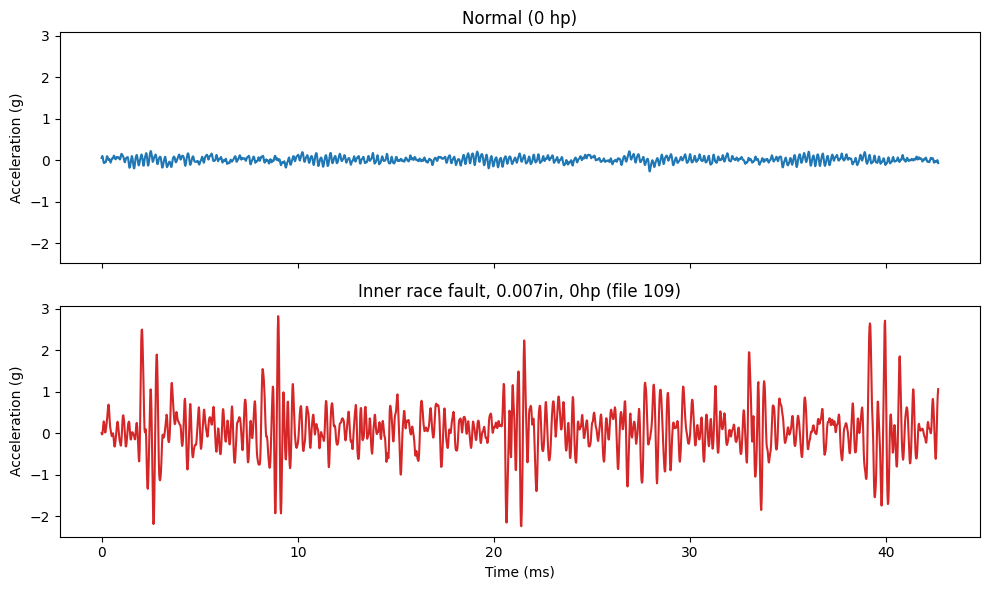

In [9]:
normal_de, *_ = load_signals(os.path.join(NORMAL_DIR, "normal_0hp.mat"))
fault_path = os.path.join(DRIVE_END_48K_DIR, "48k_drive_end_fault_inner_race_0.007in_0hp_1797rpm_109.mat")
fault_de, *_ = load_signals(fault_path)

n_samples = 2048  # zoom in on a short window rather than plotting the full multi-second signal
t = np.arange(n_samples) / SAMPLE_RATE_HZ * 1000  # ms

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
axes[0].plot(t, normal_de[:n_samples])
axes[0].set_title("Normal (0 hp)")
axes[1].plot(t, fault_de[:n_samples], color="tab:red")
axes[1].set_title("Inner race fault, 0.007in, 0hp (file 109)")
axes[1].set_xlabel("Time (ms)")
for ax in axes:
    ax.set_ylabel("Acceleration (g)")
plt.tight_layout()
plt.show()

## Frequency-domain: FFT comparison

A bearing fault typically shows up as extra energy at characteristic defect frequencies that a healthy bearing's spectrum lacks.

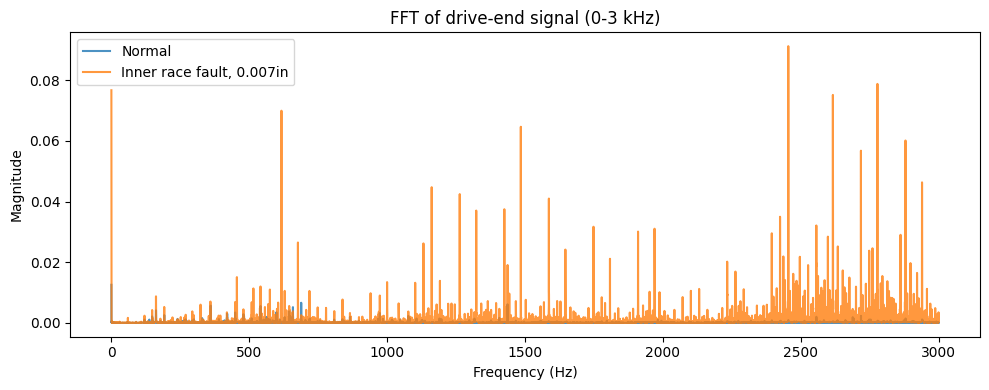

In [10]:
def spectrum(signal, sample_rate=SAMPLE_RATE_HZ):
    n = len(signal)
    freqs = np.fft.rfftfreq(n, d=1 / sample_rate)
    mags = np.abs(np.fft.rfft(signal)) / n  # normalize by length so magnitude doesn't scale with signal duration
    return freqs, mags

freq_n, mag_n = spectrum(normal_de)
freq_f, mag_f = spectrum(fault_de)

fig, ax = plt.subplots(figsize=(10, 4))
max_freq = 3000  # bearing defect frequencies of interest sit well under this for these RPMs
ax.plot(freq_n[freq_n < max_freq], mag_n[freq_n < max_freq], label="Normal", alpha=0.8)
ax.plot(freq_f[freq_f < max_freq], mag_f[freq_f < max_freq], label="Inner race fault, 0.007in", alpha=0.8)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("FFT of drive-end signal (0-3 kHz)")
ax.legend()
plt.tight_layout()
plt.show()

## Combine chosen directories into one .mat dataset

Load every file from a chosen set of directories — here `data/48k_drive_end_fault` and `data/normal_baseline_data` — and write them all into a single `combined_dataset.mat`, one MATLAB struct per source file (signals kept at their original, unsliced length) carrying both the signals and the fault metadata.

In [11]:
import scipy.io as sio

# Directories to combine — edit this list to control what goes into combined_dataset.mat
SOURCE_DIRS = [DRIVE_END_48K_DIR, NORMAL_DIR]

combine_paths = sorted(
    os.path.join(sub_dir, f)
    for sub_dir in SOURCE_DIRS
    for f in os.listdir(sub_dir)
)

combined = {}
for path in combine_paths:
    info = label_file(path)
    de, fe, ba, rpm_reported = load_signals(path)

    # savemat needs valid MATLAB identifiers as top-level variable names, so key by
    # category + id instead of the raw filename (which contains "." and other symbols).
    if info["category"] == "normal":
        var_name = f"normal_{info['load_hp']}hp"
    else:
        var_name = f"fault_{info['file_number']}"

    combined[var_name] = {
        "filename": os.path.basename(path),
        "DE_time": de if de is not None else np.array([]),
        "FE_time": fe if fe is not None else np.array([]),
        "BA_time": ba if ba is not None else np.array([]),
        "rpm_reported": rpm_reported if rpm_reported is not None else np.nan,
        # savemat can't serialize Python None, so blank out any missing fields (e.g. position on non-outer-race faults)
        **{k: (v if v is not None else "") for k, v in info.items()},
    }

output_path = os.path.join(DATA_DIR, "combined_dataset.mat")
sio.savemat(output_path, combined)
print(f"Saved {len(combined)} file-structs from {len(SOURCE_DIRS)} directories to {output_path}")

Saved 56 file-structs from 2 directories to data/combined_dataset.mat
